### Bernardino Payan ID: 9000684321 Email: b.payan8432@student.nu.edu

### Prdeciting Prostate Cancer

In [173]:
pwd

'/Users/bernardinopayan'

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import uniform, randint

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [148]:
# Data Loading and Initial Overview
df = pd.read_csv('prostate_cancer_prediction.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               27945 non-null  int64  
 1   Age                      27945 non-null  int64  
 2   Family_History           27945 non-null  object 
 3   Race_African_Ancestry    27945 non-null  object 
 4   PSA_Level                27945 non-null  float64
 5   DRE_Result               27945 non-null  object 
 6   Biopsy_Result            27945 non-null  object 
 7   Difficulty_Urinating     27945 non-null  object 
 8   Weak_Urine_Flow          27945 non-null  object 
 9   Blood_in_Urine           27945 non-null  object 
 10  Pelvic_Pain              27945 non-null  object 
 11  Back_Pain                27945 non-null  object 
 12  Erectile_Dysfunction     27945 non-null  object 
 13  Cancer_Stage             27945 non-null  object 
 14  Treatment_Recommended 

### Data Preparation

In [149]:
# Convert binary categorical variables to 0/1
binary_vars = ['Family_History', 'Race_African_Ancestry', 'Difficulty_Urinating', 'Weak_Urine_Flow', 
               'Blood_in_Urine', 'Pelvic_Pain', 'Back_Pain', 'Erectile_Dysfunction', 'Survival_5_Years', 
               'Exercise_Regularly', 'Healthy_Diet', 'Smoking_History', 'Hypertension', 'Diabetes', 
               'Follow_Up_Required', 'Genetic_Risk_Factors', 'Previous_Cancer_History', 'Early_Detection']
for var in binary_vars:
    df[var] = df[var].map({'No': 0, 'Yes': 1})

In [150]:
# Map DRE_Result and Biopsy_Result to numeric values
df['DRE_Result'] = df['DRE_Result'].map({'Normal': 0, 'Abnormal': 1})
df['Biopsy_Result'] = df['Biopsy_Result'].map({'Benign': 0, 'Malignant': 1})

In [151]:
# One-hot encode categorical variables
df = pd.get_dummies(df, columns=['Cancer_Stage', 'Treatment_Recommended', 'Alcohol_Consumption', 'Cholesterol_Level'], drop_first=True)

In [152]:
# Drop Patient_ID as it's not needed
df.drop(columns=['Patient_ID'], inplace=True)

In [155]:
# Define features and target
X = df.drop(columns=['Biopsy_Result'])
y = df['Biopsy_Result']

In [157]:
#Handle Imbalance with SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)
print(f"Resampled dataset size: {X.shape}")

Resampled dataset size: (39098, 34)


In [158]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [159]:
# Column Transformer and Pipeline Creation
numeric_features = ['Age', 'PSA_Level', 'BMI', 'Prostate_Volume', 'Screening_Age']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [160]:
# Hyperparameter Tuning (Random Forest)

param_distributions = {
    'classifier__n_estimators': randint(50, 200),
    'classifier__max_depth': randint(5, 20),
    'classifier__min_samples_split': randint(2, 10),
    'classifier__min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(pipeline, param_distributions, n_iter=20, scoring='accuracy', cv=5, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

# Best model
tuned_rf_model = random_search.best_estimator_
print("\nBest Parameters for Random Forest:")
print(random_search.best_params_)


Best Parameters for Random Forest:
{'classifier__max_depth': 18, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 100}


In [161]:
# Train and Evaluate XGBoost Model

xgb_model = XGBClassifier(scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]), random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [162]:
# Evaluate Random Forest and XGBoost

y_pred_rf = tuned_rf_model.predict(X_test)
y_pred_proba_rf = tuned_rf_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score (Random Forest): {roc_auc_score(y_test, y_pred_proba_rf)}")

print("\nEvaluation for XGBoost:")
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score (XGBoost): {roc_auc_score(y_test, y_pred_proba_xgb)}")

              precision    recall  f1-score   support

           0       0.70      0.89      0.79      3910
           1       0.85      0.63      0.72      3910

    accuracy                           0.76      7820
   macro avg       0.78      0.76      0.75      7820
weighted avg       0.78      0.76      0.75      7820

ROC-AUC Score (Random Forest): 0.8006845193320296

Evaluation for XGBoost:
              precision    recall  f1-score   support

           0       0.69      0.85      0.76      3910
           1       0.80      0.62      0.70      3910

    accuracy                           0.73      7820
   macro avg       0.75      0.73      0.73      7820
weighted avg       0.75      0.73      0.73      7820

ROC-AUC Score (XGBoost): 0.789900478149672


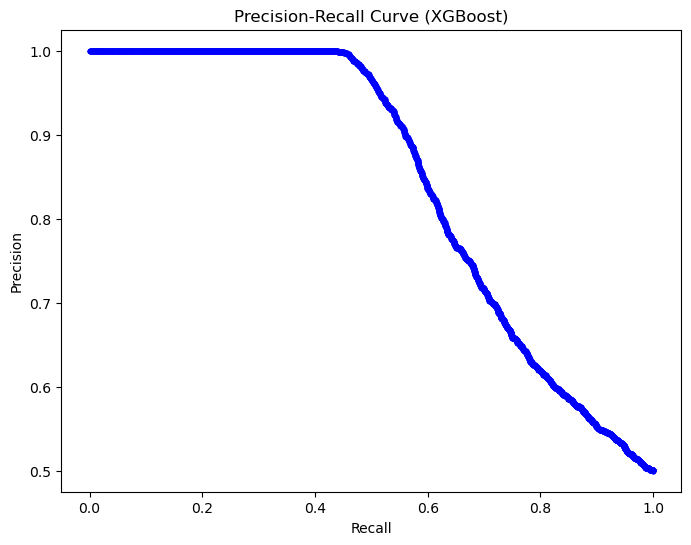

In [163]:
# Precision-Recall Curve for XGBoost

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', color='b')
plt.title('Precision-Recall Curve (XGBoost)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()


Model Evaluation Metrics (XGBoost):
MAE: 0.33257141741245144
MSE: 0.1723702802263739
RMSE: 0.41517499951993003
R2 Score: 0.3105188790945044


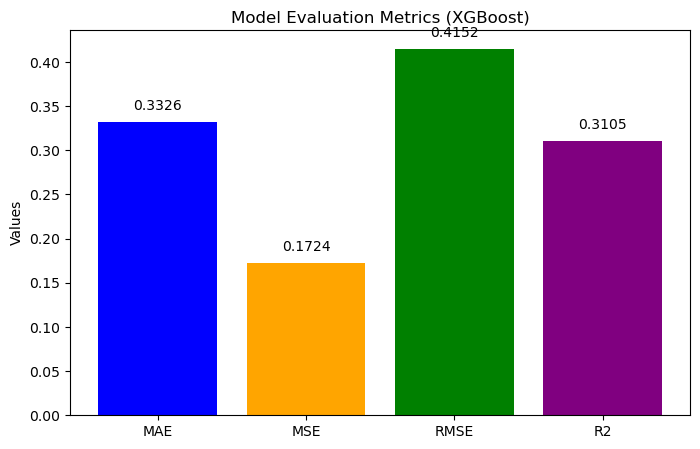

In [164]:
# Evaluation Metrics for XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_proba_xgb)
mse = mean_squared_error(y_test, y_pred_proba_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_proba_xgb)

print("\nModel Evaluation Metrics (XGBoost):")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

# Bar chart of evaluation metrics
metrics = ['MAE', 'MSE', 'RMSE', 'R2']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'orange', 'green', 'purple'])
plt.title("Model Evaluation Metrics (XGBoost)")
plt.ylabel("Values")
for i, value in enumerate(values):
    plt.text(i, value + 0.01, f'{value:.4f}', ha='center', va='bottom', fontsize=10)
plt.show()

Top 10 Important Features:
                                  Feature  Importance
32           Alcohol_Consumption_Moderate    0.133245
31                Alcohol_Consumption_Low    0.102354
26     Treatment_Recommended_Chemotherapy    0.044508
27  Treatment_Recommended_Hormone Therapy    0.040085
24                 Cancer_Stage_Localized    0.039859
30          Treatment_Recommended_Surgery    0.037343
28    Treatment_Recommended_Immunotherapy    0.036274
29        Treatment_Recommended_Radiation    0.036030
17                               Diabetes    0.033194
25                Cancer_Stage_Metastatic    0.031764


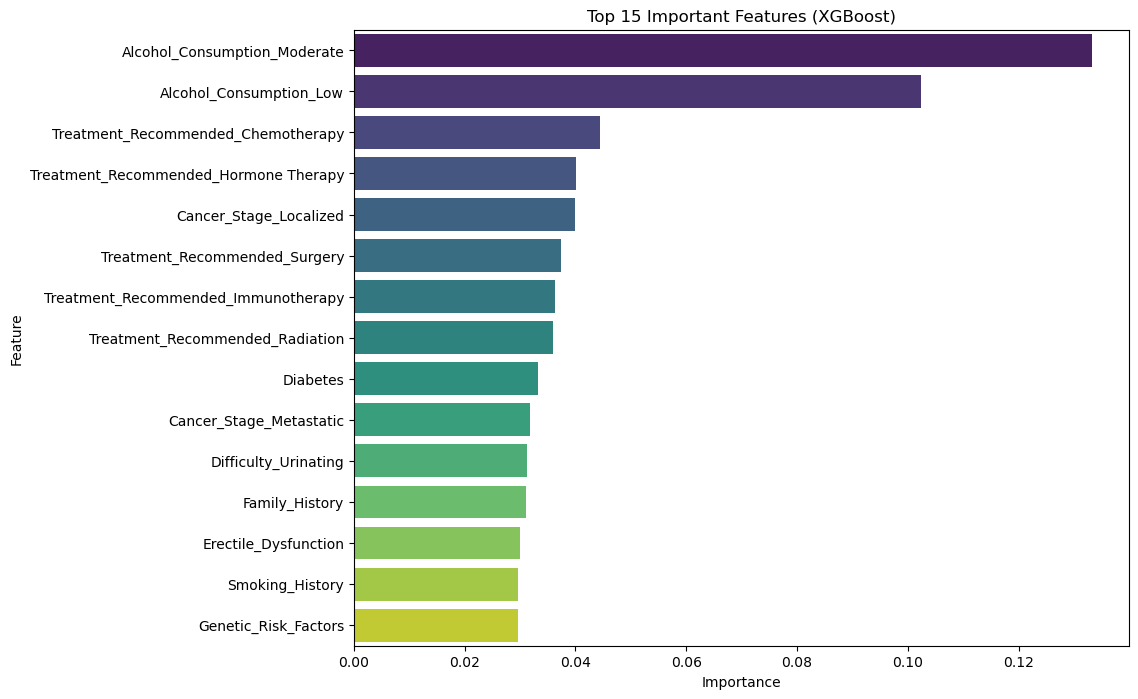

In [165]:
# Feature Importance for XGBoost

feature_importances = xgb_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 Important Features:")
print(importance_df.head(10))

# Visualize feature importance
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Important Features (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [169]:
# Save the Random Forest model
joblib.dump(tuned_rf_model, 'final_prostate_cancer_rf_model.pkl')
print("Random Forest model saved successfully.")

Random Forest model saved successfully.
